# COMP 472 — Fully Self-Contained Colab Notebook

This notebook is a standalone training runner for image classification experiments.

It includes:
- Inline experiment configs (no external YAML required)
- Dataset checks + optional download/unzip hooks
- Model factory (AlexNet / ResNet50 / MobileNetV2)
- Single experiment runner
- Batch experiment runner with filtering + skip logic
- Checkpoint/resume + best model saving
- Results table, plots, and YAML/CSV export

In [ ]:
# 1) Runtime Setup and Deterministic Seeds

import os
import csv
import time
import json
import math
import copy
import yaml
import random
import zipfile
import warnings
import pathlib
import subprocess
from pathlib import Path

warnings.filterwarnings("ignore")

# Optional package install (safe in Colab)
try:
    import sklearn
except Exception:
    subprocess.run(["pip", "install", "-q", "scikit-learn", "pandas", "matplotlib", "seaborn"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

from PIL import Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Optional wandb integration (toggle controlled in run cell)
try:
    import wandb
    WANDB_AVAILABLE = True
except Exception:
    WANDB_AVAILABLE = False


def is_colab() -> bool:
    return "COLAB_GPU" in os.environ


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


print("Running in Colab:", is_colab())
print("Device:", get_device())
print("wandb available:", WANDB_AVAILABLE)

Running in Colab: True
Device: cuda
wandb available: True


In [ ]:
# 2) Inline Configuration System (No External YAML Files)

BASE_CONFIG = {
    "experiment_name": "mobilenet_v2_five_car_models_transfer",
    "env": {
        "seed": 42,
        "output_root": "outputs",
        "local_data_root": ".",
        "colab_data_root": "/content/drive/MyDrive/processed_data",
    },
    "dataset": {
        "name": "five_car_models",
        "image_size": 224,
        "batch_size": 32,
        "num_workers": 2,
        "download_url": None,
        "zip_path": None,
        "extract_to": None,
    },
    "augmentation": {
        "random_crop": True,
        "random_crop_scale": [0.8, 1.0],
        "horizontal_flip": True,
        "rotation_degrees": 10,
        "brightness": 0.1,
        "contrast": 0.1,
    },
    "model": {
        "architecture": "mobilenet_v2",
        "pretrained": True,
        "freeze_backbone": True,
        "num_classes": 5,
    },
    "training": {
        "epochs": 50,
        "optimizer": "adamw",
        "learning_rate": 1e-3,
        "weight_decay": 1e-2,
        "scheduler": "cosine",
        "early_stopping_patience": 7,
        "unfreeze_after_epoch": 5,
        "finetune_lr": 1e-4,
        "resume": True,
    },
    "logging": {
        "save_checkpoint_every": 5,
        "log_gradcam": True,
        "log_tsne": True,
        "num_gradcam_samples": 8,
    },
}

EXPERIMENT_OVERRIDES = [
    {
        "experiment_name": "alexnet_car_brand_classification_scratch",
        "dataset": {"name": "car_brand_classification"},
        "model": {
            "architecture": "alexnet",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 33,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "alexnet_car_brand_classification_transfer",
        "dataset": {"name": "car_brand_classification"},
        "model": {
            "architecture": "alexnet",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 33,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "alexnet_five_car_models_scratch",
        "dataset": {"name": "five_car_models"},
        "model": {
            "architecture": "alexnet",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 5,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "alexnet_five_car_models_transfer",
        "dataset": {"name": "five_car_models"},
        "model": {
            "architecture": "alexnet",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 5,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "alexnet_stanford_cars_scratch",
        "dataset": {"name": "stanford_cars"},
        "model": {
            "architecture": "alexnet",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 196,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "alexnet_stanford_cars_transfer",
        "dataset": {"name": "stanford_cars"},
        "model": {
            "architecture": "alexnet",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 196,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "mobilenet_v2_car_brand_classification_scratch",
        "dataset": {"name": "car_brand_classification"},
        "model": {
            "architecture": "mobilenet_v2",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 33,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "mobilenet_v2_car_brand_classification_transfer",
        "dataset": {"name": "car_brand_classification"},
        "model": {
            "architecture": "mobilenet_v2",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 33,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "mobilenet_v2_five_car_models_scratch",
        "dataset": {"name": "five_car_models"},
        "model": {
            "architecture": "mobilenet_v2",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 5,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "mobilenet_v2_five_car_models_transfer",
        "dataset": {"name": "five_car_models"},
        "model": {
            "architecture": "mobilenet_v2",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 5,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "mobilenet_v2_stanford_cars_scratch",
        "dataset": {"name": "stanford_cars"},
        "model": {
            "architecture": "mobilenet_v2",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 196,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "mobilenet_v2_stanford_cars_transfer",
        "dataset": {"name": "stanford_cars"},
        "model": {
            "architecture": "mobilenet_v2",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 196,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "resnet50_car_brand_classification_scratch",
        "dataset": {"name": "car_brand_classification"},
        "model": {
            "architecture": "resnet50",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 33,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "resnet50_car_brand_classification_transfer",
        "dataset": {"name": "car_brand_classification"},
        "model": {
            "architecture": "resnet50",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 33,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "resnet50_five_car_models_scratch",
        "dataset": {"name": "five_car_models"},
        "model": {
            "architecture": "resnet50",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 5,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "resnet50_five_car_models_transfer",
        "dataset": {"name": "five_car_models"},
        "model": {
            "architecture": "resnet50",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 5,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "resnet50_stanford_cars_scratch",
        "dataset": {"name": "stanford_cars"},
        "model": {
            "architecture": "resnet50",
            "pretrained": False,
            "freeze_backbone": False,
            "num_classes": 196,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 0,
            "finetune_lr": 0.0001,
        },
    },
    {
        "experiment_name": "resnet50_stanford_cars_transfer",
        "dataset": {"name": "stanford_cars"},
        "model": {
            "architecture": "resnet50",
            "pretrained": True,
            "freeze_backbone": True,
            "num_classes": 196,
        },
        "training": {
            "epochs": 50,
            "learning_rate": 0.001,
            "weight_decay": 0.01,
            "optimizer": "adamw",
            "scheduler": "cosine",
            "early_stopping_patience": 7,
            "unfreeze_after_epoch": 5,
            "finetune_lr": 0.0001,
        },
    },
]


def deep_merge(base: dict, override: dict) -> dict:
    out = copy.deepcopy(base)
    for k, v in override.items():
        if isinstance(v, dict) and isinstance(out.get(k), dict):
            out[k] = deep_merge(out[k], v)
        else:
            out[k] = copy.deepcopy(v)
    return out


def build_config(override: dict) -> dict:
    cfg = deep_merge(BASE_CONFIG, override)
    validate_config(cfg)
    return cfg


def validate_config(cfg: dict):
    required = ["experiment_name", "env", "dataset", "model", "training", "logging"]
    for key in required:
        if key not in cfg:
            raise ValueError(f"Missing config section: {key}")


print(f"Inline experiments available: {len(EXPERIMENT_OVERRIDES)}")
print("Experiment indices for SINGLE_EXPERIMENT_INDEX:")
for i, e in enumerate(EXPERIMENT_OVERRIDES):
    print(f"[{i}] {e['experiment_name']}")

Inline experiments available: 18
Experiment indices for SINGLE_EXPERIMENT_INDEX:
[0] alexnet_car_brand_classification_scratch
[1] alexnet_car_brand_classification_transfer
[2] alexnet_five_car_models_scratch
[3] alexnet_five_car_models_transfer
[4] alexnet_stanford_cars_scratch
[5] alexnet_stanford_cars_transfer
[6] mobilenet_v2_car_brand_classification_scratch
[7] mobilenet_v2_car_brand_classification_transfer
[8] mobilenet_v2_five_car_models_scratch
[9] mobilenet_v2_five_car_models_transfer
[10] mobilenet_v2_stanford_cars_scratch
[11] mobilenet_v2_stanford_cars_transfer
[12] resnet50_car_brand_classification_scratch
[13] resnet50_car_brand_classification_transfer
[14] resnet50_five_car_models_scratch
[15] resnet50_five_car_models_transfer
[16] resnet50_stanford_cars_scratch
[17] resnet50_stanford_cars_transfer


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3) Dataset Download, Validation, and DataLoaders

def resolve_repo_root(env_cfg: dict) -> Path:
    return Path(env_cfg["colab_data_root"] if is_colab() else env_cfg["local_data_root"])


def maybe_download_and_extract(cfg: dict):
    ds = cfg.get("dataset")
    url = ds.get("download_url") if ds else None
    zip_path = ds.get("zip_path") if ds else None
    extract_to = ds.get("extract_to") if ds else None

    if not (url and zip_path and extract_to):
        return

    zip_path = Path(zip_path)
    extract_to = Path(extract_to)

    if not zip_path.exists():
        print(f"Downloading dataset from {url} ...")
        import urllib.request
        zip_path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(url, zip_path)

    marker = extract_to / ".unzipped"
    if not marker.exists():
        print(f"Extracting {zip_path} -> {extract_to} ...")
        extract_to.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_to)
        marker.touch()


def build_transforms(aug_cfg: dict, image_size: int, split: str):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    if split == "train":
        t = []
        if aug_cfg.get("random_crop", False):
            t.append(transforms.RandomResizedCrop(image_size, scale=tuple(aug_cfg.get("random_crop_scale", [0.8, 1.0]))))
        else:
            t.append(transforms.Resize((image_size, image_size)))

        if aug_cfg.get("horizontal_flip", False):
            t.append(transforms.RandomHorizontalFlip())

        rot = aug_cfg.get("rotation_degrees", 0)
        if rot:
            t.append(transforms.RandomRotation(rot))

        bri = aug_cfg.get("brightness", 0)
        con = aug_cfg.get("contrast", 0)
        if bri or con:
            t.append(transforms.ColorJitter(brightness=bri, contrast=con))

        t.extend([transforms.ToTensor(), transforms.Normalize(mean, std)])
        return transforms.Compose(t)

    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


class ManifestDataset(Dataset):
    def __init__(self, manifest_path: Path, repo_root: Path, class_to_idx: dict, transform=None):
        self.samples = []
        self.transform = transform
        repo_root_name = repo_root.name # e.g., 'processed_data'
        with open(manifest_path, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                relative_path_str = row["path"]
                # If the path in the manifest starts with the repo_root's name, strip it to avoid duplication.
                if relative_path_str.startswith(f"{repo_root_name}/"):
                    relative_path_str = relative_path_str[len(repo_root_name) + 1:]

                img_path = repo_root / relative_path_str
                brand_id = int(row["brand_id"])
                self.samples.append((img_path, class_to_idx[brand_id]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, y = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, y


def build_class_index(train_manifest: Path):
    id_to_name = {}
    with open(train_manifest, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            id_to_name[int(row["brand_id"])] = row["brand"]

    sorted_ids = sorted(id_to_name.keys())
    class_to_idx = {bid: i for i, bid in enumerate(sorted_ids)}
    class_names = [id_to_name[bid] for bid in sorted_ids]
    return class_to_idx, class_names


def validate_dataset_paths(cfg: dict, repo_root: Path):
    name = cfg["dataset"]["name"]
    manifest_dir = repo_root / name
    for required in ["manifest_train.csv", "manifest_val.csv"]:
        if not (manifest_dir / required).exists():
            raise FileNotFoundError(f"Missing required file: {manifest_dir / required}")


def build_dataloaders(cfg: dict):
    maybe_download_and_extract(cfg)

    ds_cfg = cfg["dataset"]
    aug_cfg = cfg["augmentation"]
    repo_root = resolve_repo_root(cfg["env"])
    validate_dataset_paths(cfg, repo_root)

    name = ds_cfg["name"]
    mdir = repo_root / name
    train_manifest = mdir / "manifest_train.csv"
    val_manifest = mdir / "manifest_val.csv"
    test_manifest = mdir / "manifest_test.csv"

    class_to_idx, class_names = build_class_index(train_manifest)

    loaders = {}
    for split, mp in {"train": train_manifest, "val": val_manifest}.items():
        ds = ManifestDataset(
            manifest_path=mp,
            repo_root=repo_root,
            class_to_idx=class_to_idx,
            transform=build_transforms(aug_cfg, ds_cfg["image_size"], split),
        )
        loaders[split] = DataLoader(
            ds,
            batch_size=ds_cfg["batch_size"],
            shuffle=(split == "train"),
            num_workers=ds_cfg.get("num_workers", 2),
            pin_memory=True,
        )

    if test_manifest.exists():
        test_ds = ManifestDataset(
            manifest_path=test_manifest,
            repo_root=repo_root,
            class_to_idx=class_to_idx,
            transform=build_transforms(aug_cfg, ds_cfg["image_size"], "test"),
        )
        loaders["test"] = DataLoader(
            test_ds,
            batch_size=ds_cfg["batch_size"],
            shuffle=False,
            num_workers=ds_cfg.get("num_workers", 2),
            pin_memory=True,
        )
    else:
        loaders["test"] = loaders["val"]

    loaders["class_names"] = class_names
    return loaders


In [ ]:
# 4) Model Factory (Transfer Learning + Classifier Head)

SUPPORTED_ARCHS = ["alexnet", "resnet50", "mobilenet_v2"]


def build_model(model_cfg: dict) -> nn.Module:
    arch = model_cfg["architecture"]
    pretrained = model_cfg.get("pretrained", True)
    freeze = model_cfg.get("freeze_backbone", False)
    num_classes = model_cfg["num_classes"]

    if arch not in SUPPORTED_ARCHS:
        raise ValueError(f"Unsupported architecture '{arch}'.")

    if arch == "alexnet":
        weights = models.AlexNet_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.alexnet(weights=weights)
        if pretrained and freeze:
            for p in model.parameters():
                p.requires_grad = False
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    elif arch == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.resnet50(weights=weights)
        if pretrained and freeze:
            for p in model.parameters():
                p.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    else:
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.mobilenet_v2(weights=weights)
        if pretrained and freeze:
            for p in model.parameters():
                p.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    return model


def unfreeze_backbone(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True


def get_param_groups(model: nn.Module, arch: str, finetune_lr: float, head_lr: float):
    if arch == "alexnet":
        head_params = list(model.classifier[6].parameters())
    elif arch == "resnet50":
        head_params = list(model.fc.parameters())
    else:
        head_params = list(model.classifier[1].parameters())

    head_ids = {id(p) for p in head_params}
    backbone_params = [p for p in model.parameters() if id(p) not in head_ids]

    return [
        {"params": backbone_params, "lr": finetune_lr},
        {"params": head_params, "lr": head_lr},
    ]

In [ ]:
# 5) Training and Validation Loops
# 6) Metrics Computation + Visualization (Accuracy, Macro-F1, CM, Grad-CAM, t-SNE)

import inspect
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
import torch.nn.functional as F


class MetricTracker:
    def __init__(self):
        self.reset()

    def reset(self):
        self.loss_sum = 0.0
        self.n = 0
        self.preds = []
        self.labels = []

    def update(self, loss: float, preds: torch.Tensor, labels: torch.Tensor):
        b = labels.size(0)
        self.loss_sum += loss * b
        self.n += b
        self.preds.extend(preds.detach().cpu().numpy())
        self.labels.extend(labels.detach().cpu().numpy())

    def compute(self) -> dict:
        y_true = np.array(self.labels)
        y_pred = np.array(self.preds)
        macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )
        per_p, per_r, per_f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0
        )
        return {
            "loss": self.loss_sum / max(self.n, 1),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_precision": float(macro_p),
            "macro_recall": float(macro_r),
            "macro_f1": float(macro_f1),
            "per_class_precision": per_p.tolist(),
            "per_class_recall": per_r.tolist(),
            "per_class_f1": per_f1.tolist(),
            "y_true": y_true,
            "y_pred": y_pred,
        }


def build_optimizer(model: nn.Module, cfg: dict):
    train_cfg = cfg["training"]
    opt = train_cfg["optimizer"].lower()
    lr = train_cfg["learning_rate"]
    wd = train_cfg["weight_decay"]

    if opt == "adamw":
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    if opt == "adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    if opt == "sgd":
        return optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    raise ValueError(f"Unknown optimizer: {opt}")


def build_scheduler(optimizer, cfg, n_epochs: int):
    sched = cfg["training"].get("scheduler", "none").lower()
    if sched == "cosine":
        return CosineAnnealingLR(optimizer, T_max=n_epochs)
    if sched == "step":
        return StepLR(optimizer, step_size=10, gamma=0.1)
    return None


def run_epoch(model, loader, criterion, optimizer, device, split: str):
    is_train = split == "train"
    model.train() if is_train else model.eval()
    tracker = MetricTracker()

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)
            tracker.update(float(loss.item()), preds, labels)

    return tracker.compute()


def compute_confusion_matrix(y_true, y_pred, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    return cm


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix", normalize=True):
    cm = compute_confusion_matrix(y_true, y_pred, normalize=normalize)
    n_classes = cm.shape[0]
    fig_size = max(8, n_classes // 4)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    if class_names and n_classes <= 30:
        ax.set_xticks(range(n_classes))
        ax.set_yticks(range(n_classes))
        ax.set_xticklabels(class_names, rotation=90, fontsize=7)
        ax.set_yticklabels(class_names, fontsize=7)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    return fig


def get_model_size(model: nn.Module):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb = total_params * 4 / (1024 ** 2)
    return {
        "total_params": int(total_params),
        "trainable_params": int(trainable_params),
        "model_size_mb": round(size_mb, 2),
    }


def measure_inference_time(model: nn.Module, loader: DataLoader, device: torch.device, n_batches: int = 10):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= n_batches:
                break
            images = images.to(device)
            start = time.perf_counter()
            _ = model(images)
            if device.type == "cuda":
                torch.cuda.synchronize()
            elapsed = (time.perf_counter() - start) * 1000
            times.append((elapsed, images.size(0)))

    total_ms = sum(t for t, _ in times)
    total_img = sum(n for _, n in times)
    return {
        "inference_total_ms": float(total_ms),
        "inference_per_image_ms": float(total_ms / max(total_img, 1)),
    }


def get_classification_report(y_true, y_pred, class_names):
    return classification_report(y_true, y_pred, target_names=class_names, zero_division=0)


class GradCAM:
    TARGET_LAYERS = {
        "alexnet": "features.12",
        "resnet50": "layer4.2.conv3",
        "mobilenet_v2": "features.18.0",
    }

    def __init__(self, model: nn.Module, arch: str):
        self.model = model
        self.arch = arch
        self._gradients = None
        self._activations = None

        target_name = self.TARGET_LAYERS.get(arch)
        if target_name is None:
            raise ValueError(f"No target layer for architecture '{arch}'")

        layer = self._get_layer(target_name)
        layer.register_forward_hook(self._save_activation)
        layer.register_full_backward_hook(self._save_gradient)

    def _get_layer(self, name: str) -> nn.Module:
        layer = self.model
        for p in name.split("."):
            layer = layer[int(p)] if p.isdigit() else getattr(layer, p)
        return layer

    def _save_activation(self, module, input, output):
        self._activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self._gradients = grad_output[0].detach()

    def generate(self, images: torch.Tensor, class_idx: torch.Tensor | None = None):
        self.model.eval()
        images = images.requires_grad_(True)
        logits = self.model(images)

        if class_idx is None:
            class_idx = logits.argmax(dim=1)

        heatmaps = []
        for i in range(images.size(0)):
            self.model.zero_grad()
            score = logits[i, class_idx[i]]
            score.backward(retain_graph=(i < images.size(0) - 1))

            weights = self._gradients[i].mean(dim=(1, 2), keepdim=True)
            cam = (weights * self._activations[i]).sum(dim=0)
            cam = F.relu(cam).cpu().numpy()
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
            heatmaps.append(cam)

        return np.stack(heatmaps)


def plot_gradcam_grid(images, heatmaps, labels, preds, class_names, title="Grad-CAM"):
    n = min(len(images), 8)
    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 6))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(n):
        img = images[i].detach().cpu().numpy().transpose(1, 2, 0)
        img = (img * std + mean).clip(0, 1)
        h, w = img.shape[:2]

        hm_resized = np.kron(
            heatmaps[i],
            np.ones((h // heatmaps[i].shape[0] + 1, w // heatmaps[i].shape[1] + 1)),
        )[:h, :w]
        hm_resized = plt.cm.jet(hm_resized)[:, :, :3]

        axes[0, i].imshow(img)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"True: {class_names[labels[i]]}", fontsize=7)

        overlay = 0.5 * img + 0.5 * hm_resized
        axes[1, i].imshow(overlay.clip(0, 1))
        axes[1, i].axis("off")
        pred_label = class_names[preds[i]]
        color = "green" if preds[i] == labels[i] else "red"
        axes[1, i].set_title(f"Pred: {pred_label}", fontsize=7, color=color)

    fig.suptitle(title)
    plt.tight_layout()
    return fig


def extract_embeddings(model: nn.Module, loader: DataLoader, device: torch.device, arch: str, max_samples: int = 1000):
    model.eval()
    embeddings, labels = [], []
    collected = 0
    captured = {}

    def hook_fn(module, inp, out):
        captured["embedding"] = out.detach().cpu()

    if arch == "alexnet":
        handle = model.classifier[5].register_forward_hook(hook_fn)
    elif arch == "resnet50":
        handle = model.avgpool.register_forward_hook(hook_fn)
    else:
        handle = model.features[-1].register_forward_hook(hook_fn)

    with torch.no_grad():
        for images, y in loader:
            if collected >= max_samples:
                break
            images = images.to(device)
            model(images)
            emb = captured["embedding"].view(captured["embedding"].size(0), -1).numpy()
            embeddings.append(emb)
            labels.append(y.numpy())
            collected += emb.shape[0]

    handle.remove()

    embeddings = np.concatenate(embeddings, axis=0)[:max_samples]
    labels = np.concatenate(labels, axis=0)[:max_samples]
    return embeddings, labels


def plot_tsne(embeddings, labels, class_names, title="t-SNE Embedding", perplexity=30):
    tsne_kwargs = {
        "n_components": 2,
        "perplexity": perplexity,
        "random_state": 42,
    }
    params = inspect.signature(TSNE.__init__).parameters
    if "max_iter" in params:
        tsne_kwargs["max_iter"] = 1000
    else:
        tsne_kwargs["n_iter"] = 1000

    coords = TSNE(**tsne_kwargs).fit_transform(embeddings)

    n_classes = len(np.unique(labels))
    cmap = plt.cm.get_cmap("tab20", n_classes)

    fig, ax = plt.subplots(figsize=(10, 8))
    for cls_idx in range(n_classes):
        mask = labels == cls_idx
        label = class_names[cls_idx] if (class_names and n_classes <= 20) else str(cls_idx)
        ax.scatter(coords[mask, 0], coords[mask, 1], color=cmap(cls_idx), label=label, s=10, alpha=0.7)

    if n_classes <= 20:
        ax.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    return fig


class NotebookWandbLogger:
    def __init__(self, cfg: dict):
        self.enabled = cfg.get("logging", {}).get("use_wandb", False) and WANDB_AVAILABLE
        self.run = None
        if self.enabled:
            self.run = wandb.init(
                project=cfg.get("logging", {}).get("wandb_project", "comp472_car_detection"),
                entity=cfg.get("logging", {}).get("wandb_entity", None),
                name=cfg["experiment_name"],
                config=cfg,
                reinit=True,
            )

    def log_epoch(self, split: str, metrics: dict, epoch: int):
        if not self.enabled:
            return
        payload = {f"{split}/{k}": v for k, v in metrics.items() if isinstance(v, (int, float, np.floating))}
        payload["epoch"] = epoch
        wandb.log(payload, step=epoch)

    def log_per_class(self, split: str, metrics: dict, class_names: list, epoch: int):
        if not self.enabled:
            return
        rows = []
        for i in range(len(metrics["per_class_f1"])):
            rows.append([
                class_names[i],
                round(metrics["per_class_precision"][i], 4),
                round(metrics["per_class_recall"][i], 4),
                round(metrics["per_class_f1"][i], 4),
            ])
        table = wandb.Table(columns=["class", "precision", "recall", "f1"], data=rows)
        wandb.log({f"{split}/per_class_metrics": table, "epoch": epoch}, step=epoch)

    def log_figure(self, key: str, fig, epoch: int | None = None):
        if not self.enabled:
            plt.close(fig)
            return
        payload = {key: wandb.Image(fig)}
        if epoch is not None:
            payload["epoch"] = epoch
            wandb.log(payload, step=epoch)
        else:
            wandb.log(payload)
        plt.close(fig)

    def log_dict(self, payload: dict):
        if self.enabled:
            wandb.log(payload)

    def log_model_artifact(self, path: str, name: str, metadata: dict | None = None):
        if not self.enabled:
            return
        artifact = wandb.Artifact(name=name, type="model", metadata=metadata or {})
        artifact.add_file(path)
        wandb.log_artifact(artifact)

    def finish(self):
        if self.enabled and self.run is not None:
            wandb.finish()

In [ ]:
# 9) Checkpointing, Resume Logic, and Best-Model Saving

def save_checkpoint(model, optimizer, scheduler, epoch, metrics, cfg, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / f"epoch_{epoch:03d}.pt"
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "sched_state": scheduler.state_dict() if scheduler else None,
        "metrics": metrics,
        "config": cfg,
    }, path)
    return path


def save_best_model(model, optimizer, epoch, metrics, cfg, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / "best_model.pt"
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "metrics": metrics,
        "config": cfg,
    }, path)
    return path


def load_checkpoint(path: Path, model, optimizer=None, scheduler=None, device=None):
    if device is None:
        device = get_device()
    if not path.exists():
        return None

    try:
        ckpt = torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location=device)

    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optim_state" in ckpt and ckpt["optim_state"] is not None:
        optimizer.load_state_dict(ckpt["optim_state"])
    if scheduler is not None and "sched_state" in ckpt and ckpt["sched_state"] is not None:
        scheduler.load_state_dict(ckpt["sched_state"])

    return ckpt


def find_latest_checkpoint(output_dir: Path):
    cks = sorted(output_dir.glob("epoch_*.pt"))
    return cks[-1] if cks else None

In [ ]:
# 7) Single Experiment Runner

def run_single_experiment(cfg: dict):
    set_seed(cfg["env"]["seed"])
    device = get_device()

    output_dir = Path(cfg["env"]["output_root"]) / cfg["experiment_name"]
    output_dir.mkdir(parents=True, exist_ok=True)

    logger = NotebookWandbLogger(cfg)

    loaders = build_dataloaders(cfg)
    class_names = loaders["class_names"]
    train_loader = loaders["train"]
    val_loader = loaders["val"]
    test_loader = loaders.get("test", val_loader)

    model = build_model(cfg["model"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(optimizer, cfg, cfg["training"]["epochs"])

    model_info = get_model_size(model)
    logger.log_dict(model_info)

    train_cfg = cfg["training"]
    n_epochs = train_cfg["epochs"]
    patience = train_cfg.get("early_stopping_patience", 7)
    unfreeze_after = train_cfg.get("unfreeze_after_epoch", 0)
    finetune_lr = train_cfg.get("finetune_lr", 1e-4)

    log_cfg = cfg.get("logging", {})
    log_every = log_cfg.get("save_checkpoint_every", 5)
    log_gradcam = log_cfg.get("log_gradcam", True)
    log_tsne = log_cfg.get("log_tsne", True)

    start_epoch = 1
    best_val_loss = float("inf")
    patience_counter = 0
    history = []
    backbone_unfrozen = False

    if train_cfg.get("resume", True):
        latest = find_latest_checkpoint(output_dir)
        if latest is not None:
            ckpt = load_checkpoint(latest, model, optimizer, scheduler, device)
            start_epoch = int(ckpt["epoch"]) + 1
            best_val_loss = float(ckpt.get("metrics", {}).get("loss", best_val_loss))
            print(f"Resumed from {latest.name} (epoch {ckpt['epoch']})")

    gradcam = None
    if log_gradcam:
        try:
            gradcam = GradCAM(model, cfg["model"]["architecture"])
        except Exception as e:
            print(f"[warn] Grad-CAM setup failed: {e}")

    for epoch in range(start_epoch, n_epochs + 1):
        if (
            cfg["model"].get("pretrained")
            and cfg["model"].get("freeze_backbone")
            and unfreeze_after > 0
            and epoch == unfreeze_after + 1
            and not backbone_unfrozen
        ):
            unfreeze_backbone(model)
            arch = cfg["model"]["architecture"]
            pg = get_param_groups(model, arch, finetune_lr, train_cfg["learning_rate"])
            optimizer = optim.AdamW(pg, weight_decay=train_cfg["weight_decay"])
            scheduler = build_scheduler(optimizer, cfg, max(1, n_epochs - epoch + 1))
            backbone_unfrozen = True
            print(f"[info] Unfroze backbone at epoch {epoch}")

        train_m = run_epoch(model, train_loader, criterion, optimizer, device, "train")
        val_m = run_epoch(model, val_loader, criterion, None, device, "val")
        if scheduler is not None:
            scheduler.step()

        history.append({
            "epoch": epoch,
            "train_loss": train_m["loss"],
            "train_acc": train_m["accuracy"],
            "train_f1": train_m["macro_f1"],
            "val_loss": val_m["loss"],
            "val_acc": val_m["accuracy"],
            "val_f1": val_m["macro_f1"],
        })

        print(
            f"Epoch {epoch:02d}/{n_epochs} | "
            f"train loss {train_m['loss']:.4f} acc {train_m['accuracy']:.4f} f1 {train_m['macro_f1']:.4f} | "
            f"val loss {val_m['loss']:.4f} acc {val_m['accuracy']:.4f} f1 {val_m['macro_f1']:.4f}"
        )

        logger.log_epoch("train", train_m, epoch)
        logger.log_epoch("val", val_m, epoch)

        if epoch % 5 == 0 or epoch == n_epochs:
            logger.log_per_class("val", val_m, class_names, epoch)

        if epoch % log_every == 0 or epoch == n_epochs:
            cm_fig = plot_confusion_matrix(
                val_m["y_true"], val_m["y_pred"], class_names,
                title=f"Val Confusion Matrix — Epoch {epoch}"
            )
            logger.log_figure("val/confusion_matrix", cm_fig, epoch)

        if gradcam and epoch in {1, max(1, n_epochs // 2), n_epochs}:
            try:
                sample_images, sample_labels = next(iter(val_loader))
                n_samples = log_cfg.get("num_gradcam_samples", 8)
                sample_images = sample_images[:n_samples].to(device)
                sample_labels = sample_labels[:n_samples]

                heatmaps = gradcam.generate(sample_images)
                with torch.no_grad():
                    preds = model(sample_images).argmax(dim=1).cpu().tolist()

                cam_fig = plot_gradcam_grid(
                    sample_images.detach(),
                    heatmaps,
                    sample_labels.tolist(),
                    preds,
                    class_names,
                    title=f"Grad-CAM Epoch {epoch}",
                )
                logger.log_figure("visualizations/grad_cam", cam_fig, epoch)
            except Exception as e:
                print(f"[warn] Grad-CAM logging failed at epoch {epoch}: {e}")

        if epoch % log_every == 0:
            save_checkpoint(model, optimizer, scheduler, epoch, val_m, cfg, output_dir)

        if val_m["loss"] < best_val_loss:
            best_val_loss = val_m["loss"]
            patience_counter = 0
            save_best_model(model, optimizer, epoch, val_m, cfg, output_dir)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    best_path = output_dir / "best_model.pt"
    load_checkpoint(best_path, model, device=device)
    completed_epochs = history[-1]["epoch"] if history else 0

    test_m = run_epoch(model, test_loader, criterion, None, device, "test")

    logger.log_epoch("test", test_m, completed_epochs)
    logger.log_per_class("test", test_m, class_names, completed_epochs)

    test_cm_fig = plot_confusion_matrix(
        test_m["y_true"], test_m["y_pred"], class_names,
        title="Test Confusion Matrix (Best Model)"
    )
    logger.log_figure("test/confusion_matrix", test_cm_fig, completed_epochs)

    if log_tsne:
        try:
            embeddings, emb_labels = extract_embeddings(
                model, val_loader, device, cfg["model"]["architecture"], max_samples=1000
            )
            tsne_fig = plot_tsne(
                embeddings,
                emb_labels,
                class_names,
                title=f"t-SNE — {cfg['experiment_name']}",
            )
            logger.log_figure("visualizations/tsne", tsne_fig, completed_epochs)
        except Exception as e:
            print(f"[warn] t-SNE failed: {e}")

    timing = measure_inference_time(model, test_loader, device)
    logger.log_dict(timing)

    report = get_classification_report(test_m["y_true"], test_m["y_pred"], class_names)
    report_path = output_dir / "classification_report.txt"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"Experiment: {cfg['experiment_name']}\n\n")
        f.write(report)

    logger.log_model_artifact(
        str(best_path),
        name=cfg["experiment_name"],
        metadata={"test_accuracy": float(test_m["accuracy"]), "test_f1": float(test_m["macro_f1"])}
    )
    logger.finish()

    metrics = {
        "status": "complete",
        "test_accuracy": float(test_m["accuracy"]),
        "test_macro_f1": float(test_m["macro_f1"]),
        "best_val_loss": float(best_val_loss),
        "output_dir": str(output_dir),
        "best_model_path": str(best_path),
        "classification_report_path": str(report_path),
        "inference_per_image_ms": float(timing["inference_per_image_ms"]),
        "trainable_params": model_info["trainable_params"],
    }

    hist_df = pd.DataFrame(history)
    hist_path = output_dir / "history.csv"
    hist_df.to_csv(hist_path, index=False)

    return {
        "config": cfg,
        "metrics": metrics,
        "history": hist_df,
        "cm": compute_confusion_matrix(test_m["y_true"], test_m["y_pred"], normalize=True),
        "class_names": class_names,
    }

In [ ]:
# 8) Batch Experiment Runner with In-Notebook Config List


def run_all_experiments_from_overrides(
    overrides_list,
    name_filter: str | None = None,
    use_wandb: bool = False,
    wandb_project: str = "comp472_car_detection",
    wandb_entity: str | None = None,
):
    results = {}
    for override in overrides_list:
        cfg = build_config(override)
        exp_name = cfg["experiment_name"]

        cfg.setdefault("logging", {})
        cfg["logging"]["use_wandb"] = use_wandb
        cfg["logging"]["wandb_project"] = wandb_project
        cfg["logging"]["wandb_entity"] = wandb_entity

        if name_filter and name_filter not in exp_name:
            continue

        best_model_path = Path(cfg["env"]["output_root"]) / exp_name / "best_model.pt"
        if best_model_path.exists():
            print(f"[skip] {exp_name} (best_model.pt exists)")
            continue

        print("\n" + "=" * 70)
        print("Starting:", exp_name)
        print("=" * 70)

        try:
            run_out = run_single_experiment(cfg)
            results[exp_name] = run_out["metrics"]
        except Exception as e:
            print(f"[ERROR] {exp_name}: {e}")
            results[exp_name] = {"status": "failed", "error": str(e)}

    return results

In [ ]:
# 10) Results Table, Plots, and YAML/CSV Export


def summarize_results(results: dict, export_dir: str = "outputs"):
    if not results:
        print("No results to summarize.")
        return pd.DataFrame()

    rows = []
    for name, r in results.items():
        rows.append({
            "experiment": name,
            "status": r.get("status", "unknown"),
            "test_accuracy": r.get("test_accuracy"),
            "test_macro_f1": r.get("test_macro_f1"),
            "best_val_loss": r.get("best_val_loss"),
            "best_model_path": r.get("best_model_path"),
        })

    df = pd.DataFrame(rows).sort_values(by=["status", "test_macro_f1"], ascending=[True, False])
    display(df)

    export_root = Path(export_dir)
    export_root.mkdir(parents=True, exist_ok=True)

    yaml_path = export_root / "experiment_summary.yaml"
    csv_path = export_root / "experiment_summary.csv"

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(results, f, sort_keys=True)
    df.to_csv(csv_path, index=False)

    ok = df[df["status"] == "complete"].copy()
    if not ok.empty:
        plt.figure(figsize=(10, 4))
        x = np.arange(len(ok))
        plt.bar(x - 0.2, ok["test_accuracy"], width=0.4, label="Accuracy")
        plt.bar(x + 0.2, ok["test_macro_f1"], width=0.4, label="Macro-F1")
        plt.xticks(x, ok["experiment"], rotation=45, ha="right")
        plt.ylim(0, 1)
        plt.title("Experiment Metrics")
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"Saved: {yaml_path}")
    print(f"Saved: {csv_path}")
    return df

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: andrewkaranu03 (andrewkaranu03-concordia-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 117MB/s]


Epoch 01/50 | train loss 1.4361 acc 0.3673 f1 0.2182 | val loss 1.3158 acc 0.5183 f1 0.3834
Epoch 02/50 | train loss 1.2877 acc 0.4669 f1 0.3298 | val loss 1.2479 acc 0.5061 f1 0.3077
Epoch 03/50 | train loss 1.1727 acc 0.5202 f1 0.4082 | val loss 1.2692 acc 0.4512 f1 0.2473
Epoch 04/50 | train loss 1.1626 acc 0.5133 f1 0.4054 | val loss 1.1921 acc 0.5244 f1 0.3797
Epoch 05/50 | train loss 1.1127 acc 0.5384 f1 0.4350 | val loss 1.2755 acc 0.4756 f1 0.2264
[info] Unfroze backbone at epoch 6
Epoch 06/50 | train loss 1.0130 acc 0.6008 f1 0.5327 | val loss 0.8913 acc 0.6829 f1 0.5070
Epoch 07/50 | train loss 0.5633 acc 0.8038 f1 0.7568 | val loss 0.8139 acc 0.7073 f1 0.6405
Epoch 08/50 | train loss 0.3971 acc 0.8586 f1 0.8386 | val loss 0.7102 acc 0.7378 f1 0.6840
Epoch 09/50 | train loss 0.2950 acc 0.8935 f1 0.8837 | val loss 0.7663 acc 0.7195 f1 0.6714
Epoch 10/50 | train loss 0.1956 acc 0.9278 f1 0.9257 | val loss 0.6006 acc 0.7927 f1 0.7420
Epoch 11/50 | train loss 0.1514 acc 0.9529 f1

best/val_loss,▁
epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
test/accuracy,▁
test/macro_f1,▁
train/accuracy,▁▂▃▃▃▄▆▇▇▇████████
train/loss,█▇▇▇▆▆▄▃▂▂▁▁▂▁▁▁▁▁
train/macro_f1,▁▂▃▃▃▄▆▇▇███▇█████
val/accuracy,▂▂▁▂▁▅▅▆▅▇█▆▇█▇▇██
val/loss,█▇█▇█▄▃▂▃▁▁▃▂▁▂▂▁▁
val/macro_f1,▃▂▁▃▁▄▆▆▆▇█▇▇██▇██
best/val_loss,0.57397



Single experiment complete:
{'status': 'complete', 'test_accuracy': 0.8727272727272727, 'test_macro_f1': 0.8386337063220812, 'best_val_loss': 0.5739664628011424, 'output_dir': 'outputs/mobilenet_v2_five_car_models_transfer', 'best_model_path': 'outputs/mobilenet_v2_five_car_models_transfer/best_model.pt'}


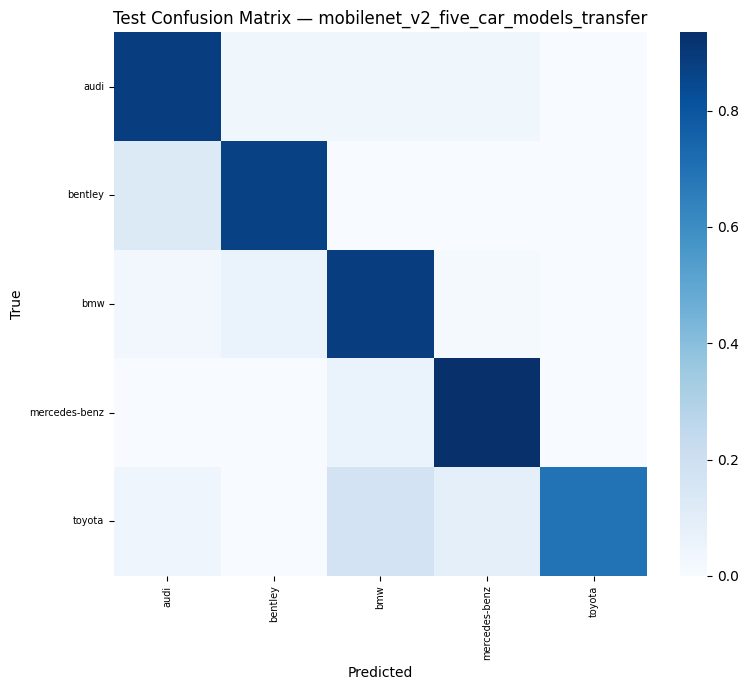

,experiment,status,test_accuracy,test_macro_f1,best_val_loss,best_model_path
0,mobilenet_v2_five_car_models_transfer,complete,0.872727,0.838634,0.573966,outputs/mobilenet_v2_five_car_models_transfer/...


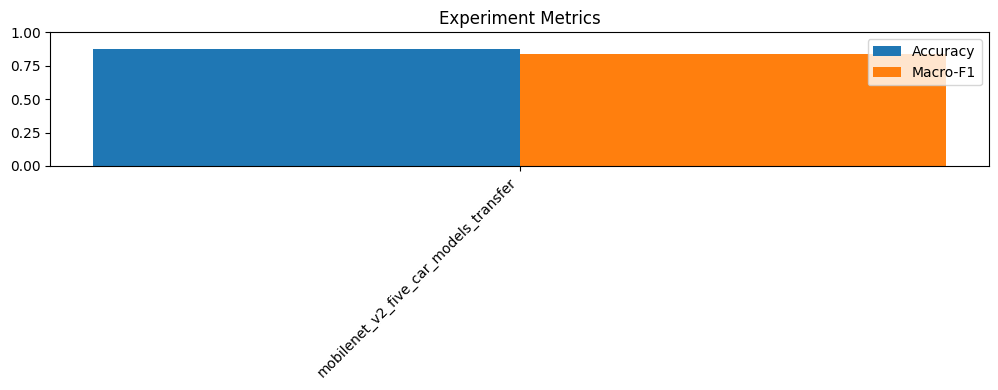

Saved: outputs/experiment_summary.yaml
Saved: outputs/experiment_summary.csv


In [ ]:
# Run Control Cell (Single or Batch)
# Execute this cell after running all previous cells.

MODE = "single"            # "single" or "all"
SINGLE_EXPERIMENT_INDEX = 9 # index in EXPERIMENT_OVERRIDES
NAME_FILTER = None

USE_WANDB = True
WANDB_PROJECT = "comp472_car_detection"
WANDB_ENTITY = None         # e.g. "your-team-or-username"

if MODE == "single":
    cfg = build_config(EXPERIMENT_OVERRIDES[SINGLE_EXPERIMENT_INDEX])
    cfg.setdefault("logging", {})
    cfg["logging"]["use_wandb"] = USE_WANDB
    cfg["logging"]["wandb_project"] = WANDB_PROJECT
    cfg["logging"]["wandb_entity"] = WANDB_ENTITY

    output = run_single_experiment(cfg)

    print("\nSingle experiment complete:")
    print(output["metrics"])

    cm = output["cm"]
    class_names = output["class_names"]
    plot_confusion(cm, class_names, title=f"Test Confusion Matrix — {cfg['experiment_name']}")

    single_results = {cfg["experiment_name"]: output["metrics"]}
    summarize_results(single_results, export_dir=cfg["env"]["output_root"])

elif MODE == "all":
    results = run_all_experiments_from_overrides(
        EXPERIMENT_OVERRIDES,
        name_filter=NAME_FILTER,
        use_wandb=USE_WANDB,
        wandb_project=WANDB_PROJECT,
        wandb_entity=WANDB_ENTITY,
    )
    summarize_results(results, export_dir=BASE_CONFIG["env"]["output_root"])

else:
    raise ValueError("MODE must be 'single' or 'all'.")